In [ ]:
# ======================================
# BƯỚC 1: MOUNT GOOGLE DRIVE
# ======================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ======================================
# BƯỚC 2: IMPORT THƯ VIỆN
# ======================================

import os
import shutil
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    ReduceLROnPlateau,
    EarlyStopping
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

In [ ]:
# ======================================
# BƯỚC 3: KIỂM TRA GPU
# ======================================

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

!nvidia-smi

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Wed Jun 10 06:13:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                        

In [ ]:
# ======================================
# BƯỚC 4: TỐI ƯU TỐC ĐỘ T4
# ======================================

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("Mixed Precision:",
      mixed_precision.global_policy())

Mixed Precision: <DTypePolicy "mixed_float16">


In [ ]:
# ======================================
# BƯỚC 5: COPY DATASET TỪ DRIVE
# GIÚP EPOCH 1 NHANH HƠN RẤT NHIỀU
# ======================================

source_dataset = "/content/drive/MyDrive/ResNet50/dataset"
target_dataset = "/content/dataset"

if not os.path.exists(target_dataset):

    print("Đang copy dataset...")

    shutil.copytree(
        source_dataset,
        target_dataset
    )

    print("Copy hoàn tất!")

else:
    print("Dataset đã tồn tại.")

Đang copy dataset...
Copy hoàn tất!


In [ ]:
# ======================================
# BƯỚC 6: THIẾT LẬP THÔNG SỐ
# ======================================

data_dir = "/content/dataset"

IMG_SIZE = (300, 300)

BATCH_SIZE = 32

EPOCHS_TRANSFER = 10

EPOCHS_FINETUNE = 10

TOTAL_EPOCHS = (
    EPOCHS_TRANSFER +
    EPOCHS_FINETUNE
)

NUM_CLASSES = 11

In [ ]:
# ======================================
# BƯỚC 7: TẠO THƯ MỤC LƯU KẾT QUẢ
# ======================================

save_dir = "/content/drive/MyDrive/ResNet50"

os.makedirs(save_dir, exist_ok=True)

print("Save folder:", save_dir)

Save folder: /content/drive/MyDrive/ResNet50


In [ ]:
# ======================================
# BƯỚC 8: IMAGE DATA GENERATOR
# ======================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [ ]:
# ======================================
# TRAIN GENERATOR
# ======================================

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 5493 images belonging to 11 classes.


In [ ]:
# ======================================
# VALIDATION GENERATOR
# ======================================

val_gen = val_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1369 images belonging to 11 classes.


In [ ]:
# ======================================
# THÔNG TIN DATASET
# ======================================

classes = list(train_gen.class_indices.keys())

print("Classes:")
print(classes)

print("\nSố lớp:", len(classes))

print("Train samples:", train_gen.samples)

print("Validation samples:", val_gen.samples)

print("Train steps:", len(train_gen))

print("Validation steps:", len(val_gen))

Classes:
['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']

Số lớp: 11
Train samples: 5493
Validation samples: 1369
Train steps: 172
Validation steps: 43


In [ ]:
# ======================================
# PHÂN BỐ DỮ LIỆU
# ======================================

from collections import Counter

counter = Counter(train_gen.classes)

print("\nSố ảnh từng lớp:")

for idx, count in counter.items():
    print(
        f"{classes[idx]} : {count}"
    )


Số ảnh từng lớp:
dew : 559
fogsmog : 681
frost : 380
glaze : 512
hail : 473
lightning : 302
rain : 421
rainbow : 186
rime : 928
sandstorm : 554
snow : 497


In [ ]:
# ======================================
# BƯỚC 13: RESNET50 BACKBONE
# ======================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)

# Freeze toàn bộ backbone
base_model.trainable = False

print("Tổng số lớp:", len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Tổng số lớp: 175


In [ ]:
# ======================================
# BƯỚC 14: MODEL
# ======================================

inputs = tf.keras.Input(shape=(300, 300, 3))

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype='float32'   # quan trọng khi dùng mixed precision
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 10, 10, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        22,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,610,251 (90.07 MB)

 Trainable params: 22,539 (88.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ======================================
# BƯỚC 15: COMPILE
# ======================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ======================================
# CALLBACKS
# ======================================

checkpoint = ModelCheckpoint(
    "/content/best_model.keras",
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# ======================================
# TRANSFER LEARNING
# ======================================

history_transfer = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_TRANSFER,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop
    ]
)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.5342 - loss: 1.4225
Epoch 1: val_accuracy improved from None to 0.86340, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 192s 996ms/step - accuracy: 0.6920 - loss: 0.9134 - val_accuracy: 0.8634 - val_loss: 0.4127 - learning_rate: 0.0010
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.8384 - loss: 0.4823
Epoch 2: val_accuracy improved from 0.86340 to 0.87436, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 146s 851ms/step - accuracy: 0.8425 - loss: 0.4750 - val_accuracy: 0.8744 - val_loss: 0.3862 - learning_rate: 0.0010
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.8662 - loss: 0.4054
Epoch 3: val_accuracy improved from 0.87436 to 0.88605, saving model to /content/best_model.keras

Epoch 3: finished saving model t

In [ ]:
# ======================================
# FINE-TUNING
# ======================================

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Fine-tuning 30 lớp cuối")

Fine-tuning 30 lớp cuối


In [ ]:
# ======================================
# RE-COMPILE
# ======================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ======================================
# TRAIN FINE-TUNING
# ======================================

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=TOTAL_EPOCHS,
    initial_epoch=EPOCHS_TRANSFER,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop
    ]
)

Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.8514 - loss: 0.4368
Epoch 11: val_accuracy did not improve from 0.89774
172/172 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8729 - loss: 0.3763 - val_accuracy: 0.8970 - val_loss: 0.3454 - learning_rate: 1.0000e-05
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.8995 - loss: 0.2991
Epoch 12: val_accuracy improved from 0.89774 to 0.90285, saving model to /content/best_model.keras

Epoch 12: finished saving model to /content/best_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 156s 905ms/step - accuracy: 0.9053 - loss: 0.2833 - val_accuracy: 0.9028 - val_loss: 0.3244 - learning_rate: 1.0000e-05
Epoch 13/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.9181 - loss: 0.2436
Epoch 13: val_accuracy did not improve from 0.90285
172/172 ━━━━━━━━━━━━━━━━━━━━ 151s 875ms/step - accuracy: 0.9179 - loss: 0.2462 - val_accuracy: 0.9014 - val_loss: 0.3112 - learning_rate: 1.0000e-05
Epoch 14/20
172/172 ━━━━

In [ ]:
save_path = "/content/drive/MyDrive/ResNet50/resnet50model.h5"

model.save(save_path, save_format="h5")
print("Đã lưu model H5 vào Google Drive:", save_path)

Đã lưu model H5 vào Google Drive: /content/drive/MyDrive/ResNet50/resnet50model.h5


In [ ]:
# ======================================
# LƯU MODEL (Keras + H5)
# ======================================

import os

save_dir = "/content/drive/MyDrive/ResNet50"
os.makedirs(save_dir, exist_ok=True)

# Lưu dạng Keras mới (khuyến nghị)
model.save(os.path.join(save_dir, "resnet50model.keras"))

# Lưu dạng H5 (legacy - vẫn dùng cho báo cáo)
model.save(os.path.join(save_dir, "resnet50model2.h5"))

print("Đã lưu cả model.keras và model.h5 vào Google Drive")

Đã lưu cả model.keras và model.h5 vào Google Drive


In [ ]:
# ======================================
# MERGE HISTORY
# ======================================

acc = history_transfer.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_transfer.history['val_accuracy'] + history_finetune.history['val_accuracy']

loss = history_transfer.history['loss'] + history_finetune.history['loss']
val_loss = history_transfer.history['val_loss'] + history_finetune.history['val_loss']

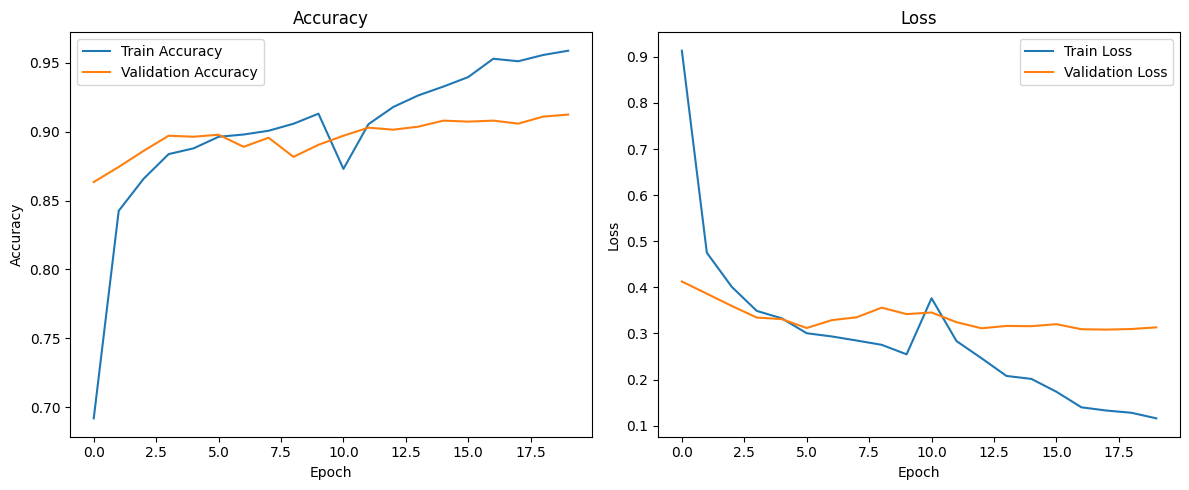

In [ ]:
# ======================================
# ACCURACY + LOSS
# ======================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/ResNet50/train_val_plot.png",
    dpi=300
)

plt.show()

In [ ]:
# ======================================
# PREDICT
# ======================================

val_gen.reset()

y_prob = model.predict(val_gen)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes

43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 329ms/step


In [ ]:
# ======================================
# CLASSIFICATION REPORT
# ======================================

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

         dew       0.94      0.96      0.95       139
     fogsmog       0.92      0.99      0.95       170
       frost       0.80      0.81      0.81        95
       glaze       0.83      0.86      0.84       127
        hail       0.98      0.94      0.96       118
   lightning       0.99      1.00      0.99        75
        rain       0.94      0.90      0.92       105
     rainbow       1.00      1.00      1.00        46
        rime       0.84      0.90      0.87       232
   sandstorm       0.98      0.91      0.95       138
        snow       0.87      0.73      0.79       124

    accuracy                           0.91      1369
   macro avg       0.92      0.91      0.91      1369
weighted avg       0.91      0.91      0.91      1369



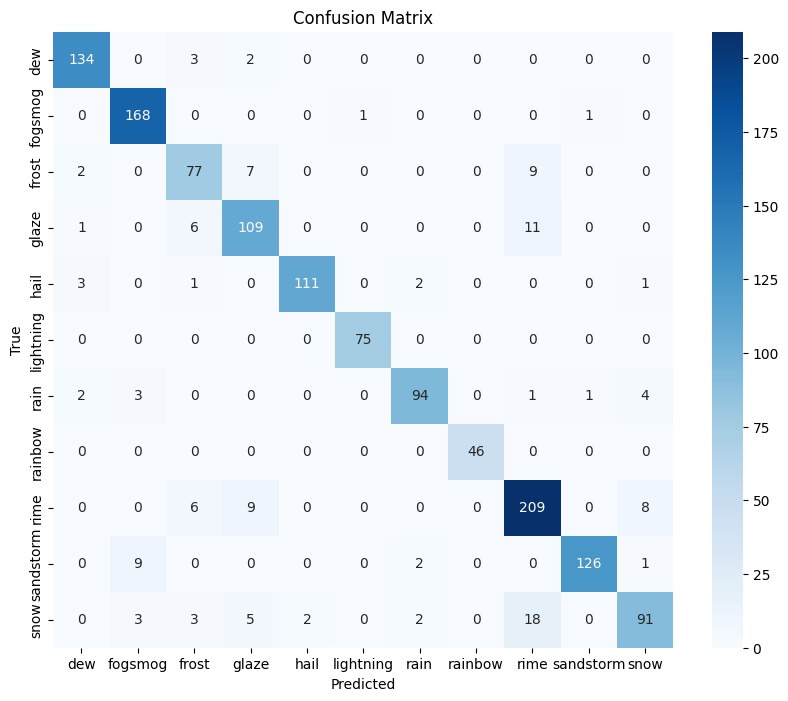

In [ ]:
# ======================================
# CONFUSION MATRIX
# ======================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig(
    "/content/drive/MyDrive/ResNet50/confusion_matrix.png",
    dpi=300
)

plt.show()

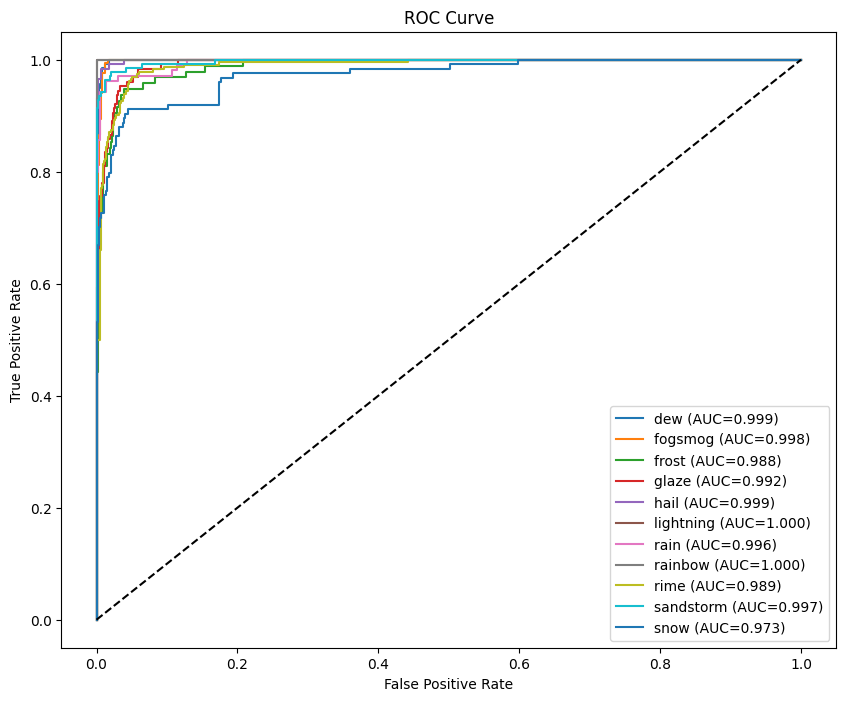

In [ ]:
# ======================================
# ROC - AUC
# ======================================

y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(10,8))

auc_scores = {}

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    auc_scores[classes[i]] = roc_auc

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/ResNet50/roc_auc.png",
    dpi=300
)

plt.show()

In [ ]:
# ======================================
# AUC SCORES
# ======================================

print("\nAUC từng lớp:\n")

for k, v in auc_scores.items():
    print(f"{k}: {v:.4f}")


AUC từng lớp:

dew: 0.9992
fogsmog: 0.9982
frost: 0.9882
glaze: 0.9923
hail: 0.9993
lightning: 1.0000
rain: 0.9955
rainbow: 1.0000
rime: 0.9893
sandstorm: 0.9974
snow: 0.9726


In [ ]:
# ======================================
# SAVE HISTORY
# ======================================

with open("/content/drive/MyDrive/ResNet50/history.pkl", "wb") as f:
    pickle.dump(
        {
            "acc": acc,
            "val_acc": val_acc,
            "loss": loss,
            "val_loss": val_loss
        },
        f
    )

print("Đã lưu history.pkl")

Đã lưu history.pkl
